In [8]:
%load_ext autoreload
%autoreload 2

import ezy_seq as ezy
#import ezy_seq.load 
import scanpy as sc
import pandas as pd
import os
from pathlib import Path  # For file path operations
import matplotlib.pyplot as plt
import napari
import glob
import numpy as np
import pathlib
from matplotlib.path import Path as MPath  # For polygon operations (matplotlib Path)
import anndata as ad
from scipy import sparse
import random
random.seed(0)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:

adata_full=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\H5ADs\E4FAD_processed.h5ad")


In [ ]:
file_path = r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\E4FAD_sample_info.xlsx"
meta_dictionary=ezy.read_dictionary(file_path)
adatas=ezy.load.cosmx(r"E:\Carter-Woods\CosMx export\E4FAD")




In [3]:

def load_polys(fp):
    if not os.path.exists(fp): return []
    df = pd.read_csv(fp)
    # pick axis columns (accept 'axis-0'/'axis-1' or first two 'axis*' matches)
    axes = ['axis-0','axis-1']
    xcol,ycol = axes[1], axes[0]
    df = df.dropna(subset=[xcol,ycol])
    return [g[[ycol,xcol]].to_numpy() for _,g in df.groupby('index')]

def load_all_polygons(project_folder):
    # Use pathlib.Path explicitly so this keeps working even if a later cell overwrites `Path`
    # (e.g., via `from matplotlib.path import Path`).
    project_folder_ = pathlib.Path(project_folder)
    polygons = {}
    for fp in project_folder_.rglob("*-polygons.csv.gz"):
        slide_name_ = fp.stem.replace("-polygons", "")
        slide_name = slide_name_.replace(".csv", "")
        polygons[slide_name] = pd.read_csv(fp)
    return polygons

project_folder = r"E:\Carter-Woods\CosMx export\E4FAD"
polygons_dict = load_all_polygons(project_folder)

layer_folders=['E4FADCtrl380R732LMCIFMT','E4FADCtrl674L539BHealthyandMCIFMT','E4FADCtrl537B070LHealthyFMT']
polygons=[]
for folder in layer_folders:
    polygons.append(polygons_dict[folder])

In [12]:
import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc
from matplotlib.path import Path

# adata_full = sc.read_h5ad(r"PATH_TO_YOUR_FILE")
base=r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD"


dfs = []
# IMPORTANT: Order matters! Regions listed later will OVERRIDE earlier ones.
# Prefrontal is placed AFTER Cortex so it takes priority for overlapping cells.
categories=['Cerebellum_Cortex.csv', 'Cerebellum_Tract.csv', 'Cortex.csv', 'Hippocampus.csv', 'Olfactory.csv', 'Unassigned.csv',  'Subiculum.csv','Striatum.csv', 'Prefrontal.csv']

# Loop through your sample lists and corresponding folders
for slide_folder in adata_full.obs['slide_ID'].unique():
    
    # 1. Create the subset for the current slide/batch
    s_df = adata_full[adata_full.obs['slide_ID']==slide_folder].copy()
    
    s_df.obs['napari_region'] = 'Unassigned'

    cell_xy = s_df.obsm['spatial_fov'][:, :2] 

    slide_path = os.path.join(base, slide_folder)

    for cat_file in categories:
        fp = os.path.join(slide_path, cat_file)

        # Skip if file doesn't exist for this slide
        if not os.path.exists(fp):
            continue

        region_name = os.path.splitext(cat_file)[0]

        df = pd.read_csv(fp)
        
        # Detect axis columns: axis-1 is X, axis-0 is Y in Napari
        xcol = 'axis-0' if 'axis-0' in df.columns else None
        ycol = 'axis-1' if 'axis-1' in df.columns else None
        
        if xcol is None or ycol is None:
            print(f"Skipping {fp}: columns need to be axis-0 and axis-1")
            continue

        # Group vertices by polygon index and test points
        hit_mask = np.zeros(len(cell_xy), dtype=bool)
        
        for _, g in df.groupby('index'):
            # Stack as (X, Y) to match cell_xy
            verts = np.column_stack((g[xcol].to_numpy(dtype=float), g[ycol].to_numpy(dtype=float)))
            
            if len(verts) < 3:  # skip degenerate polygons
                continue
            
            p = Path(verts)
            # Update mask: true if point is in ANY of the polygons for this region type
            hit_mask |= p.contains_points(cell_xy)

        # 4. Assign the region name ONLY to the 'napari_region' column
        if hit_mask.any():
            s_df.obs.loc[hit_mask, 'napari_region'] = region_name
            print(f"  -> Assigned '{region_name}': {hit_mask.sum()} cells")

    # Append processed subset to list
    print(f"Finished {slide_folder} — Region distribution:\n{s_df.obs['napari_region'].value_counts()}\n")
    dfs.append(s_df)

# Concatenate back together
adata_full = sc.concat(dfs, join='outer', axis=0, merge="first", index_unique='-')

# Optional: Convert new column to categorical for easier plotting later
adata_full.obs['napari_region'] = adata_full.obs['napari_region'].astype('category')

# Save
#save_path = "Enter your location"
adata_full.write_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\H5ADs\E4FAD_processed_4_1.h5ad")


  -> Assigned 'Cortex': 40495 cells
  -> Assigned 'Hippocampus': 6801 cells
  -> Assigned 'Subiculum': 1195 cells
  -> Assigned 'Striatum': 19664 cells
  -> Assigned 'Prefrontal': 4945 cells
Finished E4FADCtrl674L539BHealthyandMCIFMT — Region distribution:
napari_region
Unassigned     68682
Cortex         35583
Striatum       19664
Hippocampus     6784
Prefrontal      4945
Subiculum       1195
Name: count, dtype: int64

  -> Assigned 'Cerebellum_Cortex': 21148 cells
  -> Assigned 'Cerebellum_Tract': 3987 cells
  -> Assigned 'Cortex': 40679 cells
  -> Assigned 'Hippocampus': 11516 cells
  -> Assigned 'Subiculum': 2597 cells
  -> Assigned 'Striatum': 15251 cells
  -> Assigned 'Prefrontal': 5932 cells
Finished E4FADCtrl380R732LMCIFMT — Region distribution:
napari_region
Unassigned           69683
Cortex               34767
Cerebellum_Cortex    21061
Striatum             15247
Hippocampus           9793
Prefrontal            5932
Cerebellum_Tract      3987
Subiculum             2597
Name: 

In [ ]:
#Assigning samples busing Napari: Using CSV polygons
processed_adatas = []
base=r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD"
# Zip the anndata objects with their corresponding folder
for adata_full in adatas:
    if adata_full.obs['slide_ID'].unique().size>1:
        print('we have multiple slides in this object')
        continue
    slide_folder=adata_full.obs['slide_ID'].unique()[0]
    print(f"Processing slide folder: {slide_folder}")
    s_adata = adata_full.copy()
    s_adata.obs['sample_ID'] = 'Unassigned'
    

    cell_xy = np.column_stack((s_adata.obsm['spatial_fov'][:, 1], s_adata.obsm['spatial_fov'][:, 0]))
    search_path = os.path.join(base, slide_folder, "*.csv")
    print('##############################################################')
    print(search_path)
    print('##############################################################')

    found_csvs = glob.glob(search_path)
    
    if not found_csvs:
        print(f"  No CSVs found in {slide_folder}")
    
    for fp in found_csvs:
        # Extract filename to use as Sample ID
        
        file_name = os.path.basename(fp)
        sample_code = os.path.splitext(file_name)[0]
        if not sample_code[0].isdigit():
            print(f"  -> Skipping {sample_code} ")
            continue
        try:
            df = pd.read_csv(fp)
        except Exception as e:
            print(f"  Error reading {fp}: {e}")
            continue

        # Detect axis columns
        xcol = 'axis-1' if 'axis-1' in df.columns else None
        ycol = 'axis-0' if 'axis-0' in df.columns else None

        if xcol is None or ycol is None:
            print(f"  Bad cols in {fp}; need axis-0/axis-1")
            continue
        hit_mask = np.zeros(len(cell_xy), dtype=bool)
        
        for _, g in df.groupby('index'):
            verts = np.column_stack((g[xcol].to_numpy(dtype=float), g[ycol].to_numpy(dtype=float)))
            if len(verts) < 3: 
                continue
            p = MPath(verts)
            hit_mask |= p.contains_points(cell_xy)

        if hit_mask.any():
            s_adata.obs.loc[hit_mask, 'sample_ID'] = sample_code
            print(f"  Assigned '{sample_code}': {hit_mask.sum()} cells")
    
    print(f"Finished {slide_folder} — Distribution:\n{s_adata.obs['sample_ID'].value_counts()}\n")
    processed_adatas.append(s_adata)

# Merge all slides into one object
adata_full_pre = sc.concat(processed_adatas, joifn='outer', axis=0, merge="first", index_unique='-')



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
sc.pp.calculate_qc_metrics(adata_full, inplace=True)
sample_col = 'sample_ID' 
unique_samples = adata_full.obs[sample_col].unique()
for sample in unique_samples:
    subset = adata_full[adata_full.obs[sample_col] == sample]
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Sample: {sample}", fontsize=16)

    sns.histplot(data=subset.obs, x='total_counts', bins=50, kde=False, ax=ax[0], color='skyblue')
    ax[0].set_title("Distribution of Total Transcripts")
    ax[0].set_ylabel("Number of Cells")
    ax[0].set_xlabel("Total UMIs")

    sns.histplot(data=subset.obs, x='n_genes_by_counts', bins=50, kde=False, ax=ax[1], color='salmon')
    ax[1].set_title("Distribution of Unique Genes")
    ax[1].set_ylabel("Number of Cells")
    ax[1].set_xlabel("Unique Genes")

In [ ]:
#loading back in

annotate_adatas=ezy.apply_annotation(processed_adatas,meta_dictionary,cell_type_key='RNA_CosMx_Profile_Cell.Typing.InSituType.1_1_clusters')
norm_adatas=ezy.filter_and_normalize(annotate_adatas
    ,min_gene_cnt=15
    ,min_t_cnt=20)#(e.g., He et al., Nature Methods, or PMC10723440)
adata_full=sc.concat(norm_adatas, join='outer', axis=0, merge="first", index_unique='-')


Need to add to library

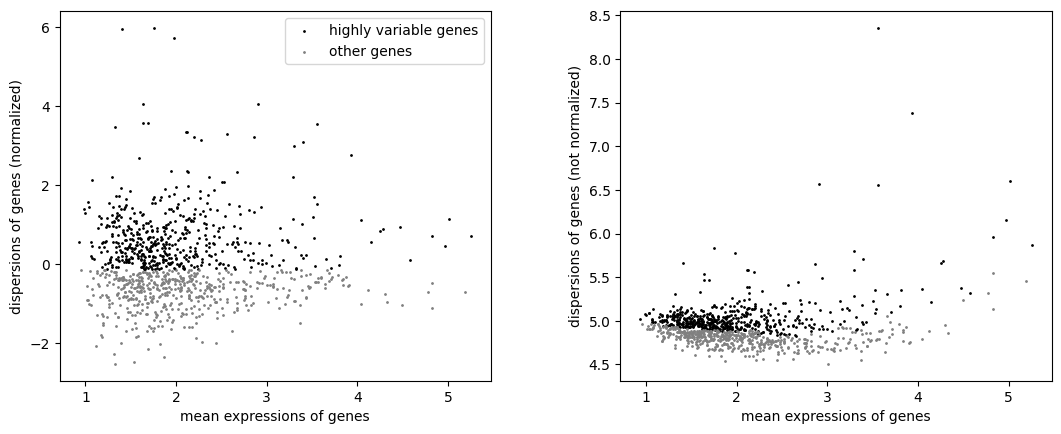

In [51]:
sc.pp.highly_variable_genes(adata_full, n_top_genes=500)
sc.pl.highly_variable_genes(adata_full)

In [ ]:
def export_anndata_for_seurat(
    adata,
    output_dir,
    *,
    counts_layer_candidates=("counts", "raw"),
    x_filename="normalized_counts.csv",
    counts_filename="raw_counts.csv",
    var_filename="features_counts.csv",
    obs_filename="cell_metadata.csv",
    coords_key="spatial_fov",
    coords_filename="coords_xy.csv",
    pca_key="X_pca",
    pca_filename="pca.csv",
    umap_key="X_umap",
    umap_filename="umap.csv",
    export_other_obsm=True,
    other_obsm_exclude=("spatial_fov", "X_pca", "X_umap"),
    verbose=True,
):
    """
    Export an AnnData object to CSVs for reconstruction in R/Seurat.

    Writes normalized_counts.csv, raw_counts.csv, features_counts.csv,
    cell_metadata.csv, coords_xy.csv, pca.csv, umap.csv, and any other
    obsm matrices as <key>.csv.  Returns a dict of written file paths.
    """
    import os
    import numpy as np
    import pandas as pd
    from scipy import sparse

    os.makedirs(output_dir, exist_ok=True)
    written = {}

    def _dense(mat):
        if sparse.issparse(mat): return mat.toarray()
        if hasattr(mat, "toarray"): return mat.toarray()
        return np.asarray(mat)

    # Raw counts
    layer = next((l for l in counts_layer_candidates if l in getattr(adata, "layers", {})), None)
    counts = adata.layers[layer] if layer else adata.X
    if layer is None and verbose:
        print("Warning: no counts layer found; using X for raw counts")
    fp = os.path.join(output_dir, counts_filename)
    pd.DataFrame(_dense(counts), index=adata.obs_names, columns=adata.var_names).to_csv(fp)
    written["counts"] = fp

    # Normalized (X)
    fp = os.path.join(output_dir, x_filename)
    pd.DataFrame(_dense(adata.X), index=adata.obs_names, columns=adata.var_names).to_csv(fp)
    written["X"] = fp

    # Metadata
    for name, fname in [(adata.var, var_filename), (adata.obs, obs_filename)]:
        fp = os.path.join(output_dir, fname)
        name.to_csv(fp)
        written[fname] = fp

    # Spatial coords
    if coords_key in getattr(adata, "obsm", {}):
        fp = os.path.join(output_dir, coords_filename)
        coords = np.asarray(adata.obsm[coords_key])[:, :2]
        pd.DataFrame(coords, index=adata.obs_names, columns=["x", "y"]).to_csv(fp)
        written["coords"] = fp

    # PCA / UMAP
    for key, fname, col_fmt in [(pca_key, pca_filename, "PC{}"), (umap_key, umap_filename, "UMAP_{}")]:
        if key in getattr(adata, "obsm", {}):
            arr = np.asarray(adata.obsm[key])
            cols = [col_fmt.format(i + 1) for i in range(arr.shape[1])]
            fp = os.path.join(output_dir, fname)
            pd.DataFrame(arr, index=adata.obs_names, columns=cols).to_csv(fp)
            written[key] = fp

    # Any other obsm
    if export_other_obsm:
        for key in adata.obsm_keys():
            if key in other_obsm_exclude: continue
            arr = np.asarray(adata.obsm[key])
            if arr.ndim != 2 or arr.shape[0] != adata.n_obs: continue
            fp = os.path.join(output_dir, f"{key}.csv")
            pd.DataFrame(arr, index=adata.obs_names,
                         columns=[f"{key}_{i+1}" for i in range(arr.shape[1])]).to_csv(fp)
            written[f"obsm:{key}"] = fp

    if verbose:
        print(f"Export complete: {len(written)} files written to {output_dir}")
    return written


In [13]:
output_dir = "./seurat_export"  # Change to your desired output directory
written_files = export_anndata_for_seurat(adata_full, output_dir)


Exporting AnnData to CSV files...
Output directory: C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\H5AD_to_rds
Using 'counts' layer for raw counts
✓ Exported counts: (432819, 1000) (cells x genes)
✓ Exported normalized data (X layer): (432819, 1000) (cells x genes)
✓ Exported gene metadata: (1000, 9)
✓ Exported cell metadata: (432819, 226)
✓ Exported spatial coordinates: (432819, 2)
✓ Exported PCA: (432819, 50)
✓ Exported UMAP: (432819, 2)
✓ Exported spatial: (432819, 2)

✓ All exports complete!
CSV files saved to: C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\H5AD_to_rds


In [12]:
print(adata_full.obs['n_genes_by_counts'])
print(adata_full.obs['nFeature_RNA'])


2_1-0         99
4_1-0         33
5_1-0         50
6_1-0         29
7_1-0        156
            ... 
474_333-5     60
475_333-5     30
476_333-5     45
479_333-5     28
481_333-5     17
Name: n_genes_by_counts, Length: 432819, dtype: int32
2_1-0         99
4_1-0         33
5_1-0         50
6_1-0         29
7_1-0        156
            ... 
474_333-5     60
475_333-5     30
476_333-5     45
479_333-5     28
481_333-5     17
Name: nFeature_RNA, Length: 432819, dtype: int64


In [47]:
#retreiving embeddings from R
new_meta=pd.read_csv(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\H5AD_to_rds\00_updated_metadata.csv",index_col=0)
new_umap=pd.read_csv(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\H5AD_to_rds\00_umap_embeddings.csv",index_col=0)
new_pca=pd.read_csv(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\H5AD_to_rds\00_pca_embeddings.csv",index_col=0)


In [ ]:
# Join new_meta, new_umap, and new_pca to adata_full

print("Joining new metadata, UMAP, and PCA to adata_full...")

# Check that indices align
print(f"\nadata_full shape: {adata_full.shape}")
print(f"new_meta shape: {new_meta.shape}")
print(f"new_umap shape: {new_umap.shape}")
print(f"new_pca shape: {new_pca.shape}")

# Check index alignment
if not adata_full.obs.index.equals(new_meta.index):
    print("\n⚠ Warning: Indices don't match exactly. Attempting to align...")
    # Align by index intersection
    common_idx = adata_full.obs.index.intersection(new_meta.index)
    print(f"  Common indices: {len(common_idx)} / {len(adata_full.obs)}")
    adata_full = adata_full[common_idx]
    new_meta = new_meta.loc[common_idx]
    new_umap = new_umap.loc[common_idx]
    new_pca = new_pca.loc[common_idx]

# 1. Join new_meta to adata_full.obs
print("\n1. Joining new_meta to adata_full.obs...")
# Add columns from new_meta that don't already exist, or update existing ones
for col in new_meta.columns:
    if col in adata_full.obs.columns:
        print(f"  Updating existing column: {col}")
    else:
        print(f"  Adding new column: {col}")
    adata_full.obs[col] = new_meta[col]

# 2. Add new_umap to adata_full.obsm
print("\n2. Adding new_umap to adata_full.obsm...")
# Convert DataFrame to numpy array and ensure it's aligned
umap_array = new_umap.values
if umap_array.shape[1] == 2:
    adata_full.obsm['X_umap'] = umap_array
    print(f"  ✓ Added UMAP embeddings: {umap_array.shape}")
else:
    print(f"  ⚠ Warning: UMAP shape is {umap_array.shape}, expected (n_cells, 2)")

# 3. Add new_pca to adata_full.obsm
print("\n3. Adding new_pca to adata_full.obsm...")
# Convert DataFrame to numpy array
pca_array = new_pca.values
adata_full.obsm['X_pca'] = pca_array
print(f"  ✓ Added PCA embeddings: {pca_array.shape}")

print("\n✓ All data joined successfully!")
print(f"\nFinal adata_full shape: {adata_full.shape}")
print(f"obs columns: {len(adata_full.obs.columns)}")
print(f"obsm keys: {list(adata_full.obsm.keys())}")


In [ ]:
#single CT probe
for sample in adata_full.obs['sample_ID'].unique():
    s_df=adata_full[adata_full.obs['sample_ID']==sample].copy()
    #slide_folder=s_df.obs['slide_ID'].unique()[0]
    #polygon_df=polygons_dict[slide_folder]

    unique_clusters = s_df.obs['seurat_clusters'].unique()
    cmap = plt.get_cmap('tab20') 
    colors_list = [cmap(i) for i in np.linspace(0, 1, len(unique_clusters))]
    
    # Create a dictionary mapping: Cluster Name -> Color
    cluster_color_dict = dict(zip(unique_clusters, colors_list))
    assigned_colors = s_df.obs['seurat_clusters'].map(cluster_color_dict).tolist()

  
    viewer = napari.Viewer()
    viewer.add_points(
        s_df.obsm['spatial_fov'], 
        size=30,
        border_width=0,
        
        # Pass the ACTUAL list of colors, not the column name
        face_color=assigned_colors,#assigned_colors,
        name="CosMx cells"
    )
    sub=s_df[s_df.obs['ct_simple']=='spiny.neurons']
    viewer.add_points(
        sub.obsm['spatial_fov'], 
        size=300,
        border_width=0,
        
        # Pass the ACTUAL list of colors, not the column name
        face_color='gold',#assigned_colors,
        name="CosMx cells"
    )

    napari.run()


In [20]:
#BEGINNING Extraction Anatomic labeling

adata_full=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\H5ADs\working.h5ad")


In [119]:
adata_full.write_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\H5ADs\working.h5ad")

In [7]:
base=r'C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD'
for slide in adata_full.obs['slide_ID'].unique():
    # Create subset for the current slide
    s_df = adata_full[adata_full.obs['slide_ID'] == slide].copy()
    #s_df = s_df[s_df.obs['sample_ID'] != '658B'].copy()
    print(f"Processing slide: {slide}")
    
    # --- 1. PREPARE COLORS (Your original code) ---
    color_by='seurat_clusters'
    unique_clusters = s_df.obs[color_by].unique()
    cmap = plt.get_cmap('tab20') 
    colors_list = [cmap(i) for i in np.linspace(0, 1, len(unique_clusters))]
    
    cluster_color_dict = dict(zip(unique_clusters, colors_list))
    assigned_colors = s_df.obs[color_by].astype(object).map(cluster_color_dict).tolist()

    # --- 2. INITIALIZE VIEWER & ADD POINTS (Your original code) ---
    viewer = napari.Viewer()

    # Base cells
    viewer.add_points(
        s_df.obsm['spatial_fov'], 
        size=100,
        border_width=0.0,
        face_color=assigned_colors,
        name=slide
    )
    

    slide_folder_path = os.path.join(base, slide)
    search_path = os.path.join(slide_folder_path, "*.csv")
    found_csvs = glob.glob(search_path)
    
    if not found_csvs:
        print(f"  -> No polygon CSVs found in {slide_folder_path}")
    
    for fp in found_csvs:

        region_name = os.path.splitext(os.path.basename(fp))[0]
        #if any(char.isdigit() for char in region_name):
        #    print(f"  -> Skipping {region_name} (contains numbers)")
        #    continue

        df = pd.read_csv(fp)
        
        xcol = 'axis-0' if 'axis-0' in df.columns else None
        ycol = 'axis-1' if 'axis-1' in df.columns else None
        
        if xcol and ycol:
            polygons_list = []
            
            for _, g in df.groupby('index'):
                verts = np.column_stack((g[xcol].to_numpy(dtype=float), g[ycol].to_numpy(dtype=float)))
                
                # --- CRITICAL FIX HERE ---
                # Skip if fewer than 3 vertices (prevents the ValueError)
                if len(verts) < 3:
                    continue
                
                polygons_list.append(verts)
            
            # Only add layer if we actually found valid polygons
            if polygons_list:
                shapes_layer = viewer.add_shapes(
                    polygons_list,
                    shape_type='polygon',
                    edge_width=20,
                    edge_color='white',
                    face_color=[0.8, 0.8, 0.8, 0.8],
                    name=f"{region_name}"
                )
         

                print(f"  -> Added shapes for {region_name}")



Processing slide: E4FADCtrl674L539BHealthyandMCIFMT


  -> Added shapes for 539B
  -> Added shapes for 674L
  -> Added shapes for Cortex
  -> Added shapes for Hippocampus
  -> Added shapes for Prefrontal
  -> Added shapes for Striatum
  -> Added shapes for Subiculum
Processing slide: E4FADCtrl380R732LMCIFMT


  -> Added shapes for 380R
  -> Added shapes for 732L
  -> Added shapes for Cerebellum_Cortex
  -> Added shapes for Cerebellum_Tract
  -> Added shapes for Cortex
  -> Added shapes for Hippocampus
  -> Added shapes for Prefrontal
  -> Added shapes for Striatum
  -> Added shapes for Subiculum
Processing slide: E4FADCtrl537B070LHealthyFMT


  -> Added shapes for 070L
  -> Added shapes for 537B
  -> Added shapes for Cerebellum_Cortex
  -> Added shapes for Cerebellum_Tract
  -> Added shapes for Cortex
  -> Added shapes for Hippocampus
  -> Added shapes for Prefrontal
  -> Added shapes for Striatum
  -> Added shapes for Subiculum


In [23]:
import pandas as pd

metadata_path = r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\E4FAD_sample_info.xlsx"
meta_df = pd.read_excel(metadata_path)

fmt_mapper = dict(zip(meta_df['sample_ID'], meta_df['FMT']))

# 4. Apply the mapping to your AnnData object
# This assumes 'adata_full' is your AnnData object and it has a 'sample_ID' column
if 'sample_ID' in adata_full.obs.columns:
    adata_full.obs['FMT'] = adata_full.obs['sample_ID'].map(fmt_mapper)
    print("Successfully added 'FMT' column to adata_full.obs")
else:
    print("Error: 'sample_ID' column not found in adata_full.obs")

# Optional: Check for unmapped values (NaNs)
if adata_full.obs['FMT'].isnull().any():
    print("Warning: Some entries did not find a match in the metadata file.")

Successfully added 'FMT' column to adata_full.obs


In [118]:
adata_full

AnnData object with n_obs × n_vars = 432819 × 1000
    obs: 'cell_type', 'RNA_CosMx_Profile_Cell.Typing.InSituType.1_1_posterior_probability', 'RNA_ABA_ref_matrix_Cell.Typing.InSituType.1_1_clusters', 'RNA_ABA_ref_matrix_Cell.Typing.InSituType.1_1_posterior_probability', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA', 'Max.rRNA', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'cell_id', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_q

In [4]:
adata_full.obs['FMT'].unique()

['Healthy', 'MCI']
Categories (2, object): ['Healthy', 'MCI']

In [ ]:
#sc.pl.umap(adata_full[adata_full.obs['ct_simple']=='spiny.neurons'], color='ct_simple', show=False)
#sc.pl.umap(adata_full[adata_full.obs['ct_simple']=='spiny.neurons'], color='ct_simple', show=False)
sc.pl.umap(adata_full, color='ct_simple', show=False)
sc.pl.umap(adata_full[adata_full.obs['FMT']=='Healthy'], color='ct_simple', show=False)
sc.pl.umap(adata_full[adata_full.obs['FMT']=='MCI'], color='ct_simple', show=False)


C:\Users\woods\AppData\Local\Temp\ipykernel_45992\2539970490.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = ds.obs.groupby([strata_col, "ct_simple"]).size()
C:\Users\woods\AppData\Local\Temp\ipykernel_45992\2539970490.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts


Treatment
Sham         151135
Treatment    135387
dtype: int64
Treatment                             Sham  Treatment
ct_simple                                            
Excitatory.neurons               35.996956  30.352988
Astrocytes                        9.852781  10.244706
Spiny.neurons                     8.846396  11.189405
Inhibitory.neurons                8.606875   8.407011
Mature.oligodendrocytes           5.384590   6.502101
Myelin.forming.oligodendrocytes   4.528402   5.889044
Endothelial.cells                 3.938201   5.250873
Committed.oligodendrocytes        3.598108   4.303220
Pericytes                         2.687002   3.675390
Neuroblasts                       3.491580   2.185587
Interneurons                      2.769048   2.235074
Vascular.leptomeningeal.cells     2.518278   1.757924
Vascular.smooth.muscle.cells      2.034605   2.153087
Perivascular.macrophages          1.816257   2.306721
Microglia                         1.904258   2.016442
Granule.neurons    

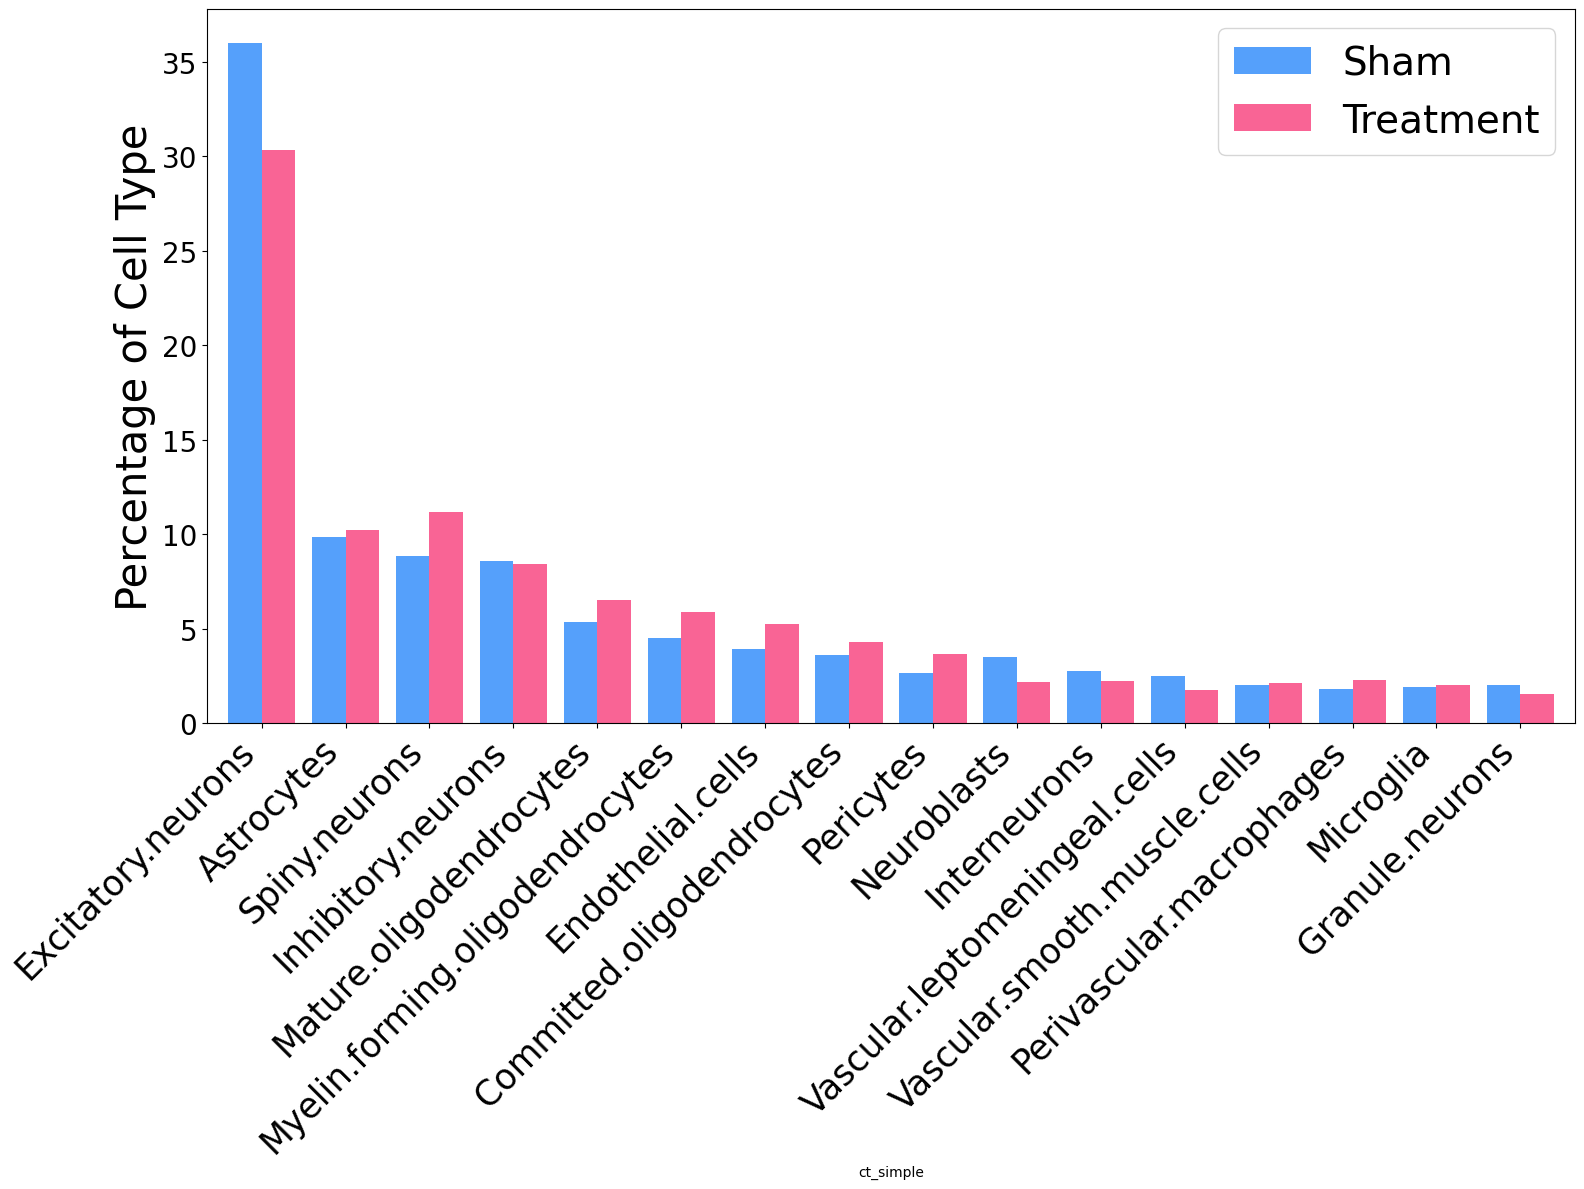

In [25]:
#create bar graphs
import matplotlib.ticker as ticker
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
stroke_color = (249/255,100/255,149/255)
healthy_color=(85/255,160/255,251/255)
cntrl_color=(184/255,86/255,215/255)



strata_col='Treatment'
strata_options=['Sham','Treatment']
def plot_celltype_counts_per_FMT(adata, top_n):
    #ds = adata[adata.obs["tissue"].isin(["Hippocampus", "Cortex"])].copy()
    ds=adata
    counts = ds.obs.groupby([strata_col, "ct_simple"]).size()
    top_clusters = (
        counts
        .groupby(level="ct_simple")
        .sum()
        .nlargest(top_n)
        .index
    )
    df = counts.unstack(level=strata_col).loc[top_clusters].fillna(0)
    df = df[strata_options]
    print(df.sum(axis=0))
    df_percent = df.div(df.sum(axis=0), axis=1) * 100
    print(df_percent)

    ax = df_percent.plot(
        kind="bar",
        color={strata_options[0]: healthy_color, strata_options[1]: stroke_color},
        figsize=(16, 12),
        width=0.8,
    )




    # after ax = df.plot(...)
   
    ax.legend( fontsize=28, title_fontsize=30, loc="upper right")
    ax.set_ylabel("Percentage of Cell Type", fontsize=30)
    print(f"Cell Cluster Abundance: Stroke-FMT vs. Healthy-FMT")
    ax.tick_params(axis='x', labelsize=25)
    ax.tick_params(axis='y', labelsize=20)

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()


# usage
plot_celltype_counts_per_FMT(adata_full, top_n=16)
#send_cell_counts_to_csv(raw_concat)

In [49]:
# Create ct_simple column: Extract simplified cell types from region-specific names
# This reduces cell types like "Astrocytes.cortex.hippocampus" to just "Astrocytes"

# Get all unique cell types
unique_cell_types = adata_full.obs['cell_type'].unique()
print(f"Found {len(unique_cell_types)} unique cell types")

# Define multi-part patterns that should be kept together
# These patterns will be preserved as-is (e.g., "Excitatory.neurons.layer.1" -> "Excitatory.neurons")
multi_part_patterns = [
    "Excitatory.neurons",
    "Inhibitory.neurons", 
    "Interneuron",
    "Interneurons",
    "Astrocytes"
]

# Define cell types that should remain unchanged (no simplification)
unchanged_types = [
    "Mature.oligodendrocytes",
    "Myelin.forming.oligodendrocytes",
    "Committed.oligodendrocytes",
    "Granule.neurons",
    "Oligodendrocyte.precursor.cells",
    "Vascular.leptomeningeal.cells",
    "Vascular.smooth.muscle.cells",
    "Astrocytes.Bergmann.glia",
    "Purkinje.cells",
    "Radial.glia",
    "Ependymal.cells",
    "Neurogliaform.cells",
    "T.cell",
    "Serotonergic.neurons",
    "Newly.formed.oligodendrocytes",
    "CCK.interneurons",
    "Dopaminergic.neurons",
    "Peptidergic.neurons",
    "Olfactory.ensheathing.cells",
    "Cajal.Retzius.cells"
]

# Define specific mappings for special cases
special_mappings = {
    # --- FIX: Ensure all Interneuron variants map to the PLURAL "Interneurons" ---
    "Interneuron": "Interneurons",             
    "Inhibitory.interneurons": "Interneurons", 
    "Interneuron.selective.interneurons": "Interneurons",
    
    # Original mappings
    "D1.medium.spiny.neurons": "Spiny.neurons",
    "D2.medium.spiny.neurons": "Spiny.neurons",
    "Cholinergic.neurons.habenula": "Cholinergic.neurons",
    "Vascular.endothelial.cells": "Endothelial.cells",
    "Telencephalon.inhibitory.neurons": "Inhibitory.neurons",
    "Choroid.plexus.epithelial.cells": "Epithelial.cells",
    "Olfactory.bulb.inhibitory.neurons": "Inhibitory.neurons",
    "Hindbrain.inhibitory.neurons": "Inhibitory.neurons",
    "Hindbrain.excitatory.neurons": "Excitatory.neurons",

}

# Simplify these by stripping suffixes (Prefix -> General)
multi_part_patterns = [
    "Excitatory.neurons",
    "Inhibitory.neurons", 
    "Interneurons",
    "Astrocytes"
    # Note: "Interneuron" (singular) removed from patterns to avoid partial matches returning singular
]

# 2. Define Function
# ------------------
def extract_simple_cell_type(cell_type):
    if pd.isna(cell_type):
        return cell_type
    
    ct_str = str(cell_type)
    
    # Priority 1: Unchanged (Catch specific complex names first)
    if ct_str in unchanged_types:
        return ct_str
    
    # Priority 2: Special Mappings (Fix specific overrides BEFORE pattern matching)
    if ct_str in special_mappings:
        return special_mappings[ct_str]
    
    # Priority 3: Pattern Matching (Prefix)
    for pattern in multi_part_patterns:
        # Check if it IS the pattern or STARTS with pattern + dot
        if ct_str == pattern or ct_str.startswith(pattern + "."):
            return pattern

    # Priority 4: Catch-all for singular "Interneuron" pattern misses
    if ct_str.startswith("Interneuron."):
        return "Interneurons"
            
    # Priority 5: Fallback
    return ct_str

# 3. Apply Optimization
# ---------------------
print("\nGenerating mapping dictionary...")

# Get unique types and create a lookup dictionary
unique_types = adata_full.obs['cell_type'].unique()
type_mapping_dict = {ct: extract_simple_cell_type(ct) for ct in unique_types}

# Map the dictionary to the column
adata_full.obs['ct_simple'] = adata_full.obs['cell_type'].map(type_mapping_dict)

# 4. Validation
# -------------
print("\n✓ ct_simple column created!")
print(f"Original unique types: {len(unique_types)}")
print(f"New unique types:      {adata_full.obs['ct_simple'].nunique()}")

print("\nValue counts for ct_simple:")
print(adata_full.obs['ct_simple'].value_counts())

Found 56 unique cell types

Generating mapping dictionary...

✓ ct_simple column created!
Original unique types: 56
New unique types:      34

Value counts for ct_simple:
ct_simple
Excitatory.neurons                 89032
Inhibitory.neurons                 42112
Mature.oligodendrocytes            35209
Neuroblasts                        34021
Astrocytes                         28683
Spiny.neurons                      26120
Cholinergic.neurons                19616
Myelin.forming.oligodendrocytes    19486
Interneurons                       19042
Committed.oligodendrocytes         17403
Perivascular.macrophages           13293
Microglia                          10691
Endothelial.cells                   9619
Hypendymal                          9591
Pericytes                           6943
T.cell                              6287
Vascular.smooth.muscle.cells        5777
Oligodendrocyte.precursor.cells     5317
Vascular.leptomeningeal.cells       5298
Radial.glia                         5004

C:\Users\woods\AppData\Local\Temp\ipykernel_36680\1384172350.py:109: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata_full.obs['ct_simple'] = adata_full.obs['cell_type'].map(type_mapping_dict)


Napari Labeling

In [10]:
base=r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD"
for slide in adata_full.obs['slide_ID'].unique():
    # Create subset for the current slide
    s_df = adata_full[adata_full.obs['slide_ID'] == slide].copy()
    
    print(f"Processing slide: {slide}")
    
    # --- 1. PREPARE COLORS (Your original code) ---
    unique_clusters = s_df.obs['ABA_ref_matrix_Neighbor.network.expression.space.1_1_cluster_ABA_ref_matrix_Leiden.Clustering.1_1'].unique()
    cmap = plt.get_cmap('tab20') 
    colors_list = [cmap(i) for i in np.linspace(0, 1, len(unique_clusters))]
    
    cluster_color_dict = dict(zip(unique_clusters, colors_list))
    assigned_colors = s_df.obs['ABA_ref_matrix_Neighbor.network.expression.space.1_1_cluster_ABA_ref_matrix_Leiden.Clustering.1_1'].astype(object).map(cluster_color_dict).tolist()

    # --- 2. INITIALIZE VIEWER & ADD POINTS (Your original code) ---
    viewer = napari.Viewer()
    
    # Base cells
    viewer.add_points(
        s_df.obsm['spatial_fov'], 
        size=200,
        border_width=0.0,
        face_color=assigned_colors,
        name=slide
    )

    slide_folder_path = os.path.join(base, slide)
    search_path = os.path.join(slide_folder_path, "*.csv")
    found_csvs = glob.glob(search_path)
    
    if not found_csvs:
        print(f"  -> No polygon CSVs found in {slide_folder_path}")
    
    for fp in found_csvs:

        region_name = os.path.splitext(os.path.basename(fp))[0]
        if any(char.isdigit() for char in region_name):
            print(f"  -> Skipping {region_name} (contains numbers)")
            continue

        df = pd.read_csv(fp)
        
        xcol = 'axis-0' if 'axis-0' in df.columns else None
        ycol = 'axis-1' if 'axis-1' in df.columns else None
        
        if xcol and ycol:
            polygons_list = []
            
            for _, g in df.groupby('index'):
                verts = np.column_stack((g[xcol].to_numpy(dtype=float), g[ycol].to_numpy(dtype=float)))
                
                # --- CRITICAL FIX HERE ---
                # Skip if fewer than 3 vertices (prevents the ValueError)
                if len(verts) < 3:
                    continue
                
                polygons_list.append(verts)
            
            # Only add layer if we actually found valid polygons
            if polygons_list:
                viewer.add_shapes(
                    polygons_list,
                    shape_type='polygon',
                    edge_width=20,
                    edge_color='white',
                    face_color=[0.8, 0.8, 0.8, 0.8],
                    name=f"{region_name}"
                )
                print(f"  -> Added shapes for {region_name}")


Processing slide: E4FADCtrl674L539BHealthyandMCIFMT
  -> Skipping 539B (contains numbers)
  -> Skipping 674L (contains numbers)
  -> Added shapes for Cortex
  -> Added shapes for Hippocampus
  -> Added shapes for Prefrontal
  -> Added shapes for Striatum
Processing slide: E4FADCtrl380R732LMCIFMT
  -> Skipping 380R (contains numbers)
  -> Skipping 732L (contains numbers)
  -> Added shapes for Cerebellum_Cortex
  -> Added shapes for Cerebellum_Tract
  -> Added shapes for Cortex
  -> Added shapes for Hippocampus
  -> Added shapes for Prefrontal
  -> Added shapes for Striatum
Processing slide: E4FADCtrl537B070LHealthyFMT
  -> Skipping 070L (contains numbers)
  -> Skipping 537B (contains numbers)
  -> Added shapes for Cerebellum_Cortex
  -> Added shapes for Cerebellum_Tract
  -> Added shapes for Cortex
  -> Added shapes for Hippocampus
  -> Added shapes for Prefrontal
  -> Added shapes for Striatum


In [50]:
import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc
from matplotlib.path import Path

# adata_full = sc.read_h5ad(r"PATH_TO_YOUR_FILE")
base=r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD"


dfs = []
# IMPORTANT: Order matters! Regions listed later will OVERRIDE earlier ones.
# Prefrontal is placed AFTER Cortex so it takes priority for overlapping cells.
categories=['Cerebellum_Cortex.csv', 'Cerebellum_Tract.csv', 'Cortex.csv', 'Hippocampus.csv', 'Olfactory.csv', 'Unassigned.csv', 'Striatum.csv', 'Prefrontal.csv']

# Loop through your sample lists and corresponding folders
for slide_folder in adata_full.obs['slide_ID'].unique():
    
    # 1. Create the subset for the current slide/batch
    s_df = adata_full[adata_full.obs['slide_ID']==slide_folder].copy()
    
    # Initialize the NEW 'napari_region' column
    # Default to 'Unassigned' (or 'Background')
    s_df.obs['napari_region'] = 'Unassigned'

    # 2. Set up coordinates
    # Note: Napari exports usually include axis-0 (Y) and axis-1 (X).
    # We need to ensure we compare (X, Y) cells to (X, Y) vertices.
    # Assuming obsm['spatial_fov'] is standard Scanpy (X, Y):
    cell_xy = s_df.obsm['spatial_fov'][:, :2] 

    # 3. Process CSVs in the ORDER defined in 'categories' (not glob order)
    # This ensures Prefrontal overrides Cortex
    slide_path = os.path.join(base, slide_folder)
    
    for cat_file in categories:
        fp = os.path.join(slide_path, cat_file)
        
        # Skip if file doesn't exist for this slide
        if not os.path.exists(fp):
            continue

        print(fp)
        region_name = os.path.splitext(cat_file)[0]

        df = pd.read_csv(fp)
        
        # Detect axis columns: axis-1 is X, axis-0 is Y in Napari
        xcol = 'axis-0' if 'axis-0' in df.columns else None
        ycol = 'axis-1' if 'axis-1' in df.columns else None
        
        if xcol is None or ycol is None:
            print(f"Skipping {fp}: columns need to be axis-0 and axis-1")
            continue

        # Group vertices by polygon index and test points
        hit_mask = np.zeros(len(cell_xy), dtype=bool)
        
        for _, g in df.groupby('index'):
            # Stack as (X, Y) to match cell_xy
            verts = np.column_stack((g[xcol].to_numpy(dtype=float), g[ycol].to_numpy(dtype=float)))
            
            if len(verts) < 3:  # skip degenerate polygons
                continue
            
            p = Path(verts)
            # Update mask: true if point is in ANY of the polygons for this region type
            hit_mask |= p.contains_points(cell_xy)

        # 4. Assign the region name ONLY to the 'napari_region' column
        if hit_mask.any():
            s_df.obs.loc[hit_mask, 'napari_region'] = region_name
            print(f"  -> Assigned '{region_name}': {hit_mask.sum()} cells")

    # Append processed subset to list
    print(f"Finished {slide_folder} — Region distribution:\n{s_df.obs['napari_region'].value_counts()}\n")
    dfs.append(s_df)

# Concatenate back together
adata_full = sc.concat(dfs, join='outer', axis=0, merge="first", index_unique='-')

# Optional: Convert new column to categorical for easier plotting later
adata_full.obs['napari_region'] = adata_full.obs['napari_region'].astype('category')

# Save
#save_path = r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\Methods_Manu\napari_labeled.h5ad"
#adata_full.write_h5ad(save_path)


C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\E4FADCtrl674L539BHealthyandMCIFMT\Cortex.csv
  -> Assigned 'Cortex': 40495 cells
C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\E4FADCtrl674L539BHealthyandMCIFMT\Hippocampus.csv
  -> Assigned 'Hippocampus': 6739 cells
C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\E4FADCtrl674L539BHealthyandMCIFMT\Striatum.csv
  -> Assigned 'Striatum': 19664 cells
C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\E4FADCtrl674L539BHealthyandMCIFMT\Prefrontal.csv
  -> Assigned 'Prefrontal': 4945 cells
Finished E4FADCtrl674L539BHealthyandMCIFMT — Region distribution:
napari_region
Unassigned     69922
Cortex         35583
Striatum       19664
Hippocampus     6739
Prefrontal      4945
Name: c

Bringing Quint Coords into AnnData

In [59]:
adata_full=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\Vignette_project\H5ADs\quint_o_updated_12_10.h5ad")


In [12]:
quint_df=pd.read_csv("C:/Users/woods/OneDrive - University of Missouri/General - Lin Brain Lab - Ogrp/Carter Woods/CosMx_Processing/E4FAD/quint.csv",index_col=0)


If reindexing is required

In [95]:
adata_full.obs.index = adata_full.obs.index.map(lambda x: '-'.join(x.split('-')[:-2]))

In [96]:
adata_full.obs["quint_region"] = quint_df["quint_region"]

In [98]:
adata_full.obs["quint_region"].value_counts()

quint_region
Cerebral Nuclei, Striatum                                   58621
Fiber tract                                                 47545
Cerebellar cortex                                           40016
Cortex, Somatamotor areas                                   39109
Cortex, Somatasensory areas                                 29249
Cerebral Nuclei, Pallidum                                   22832
Ventral group dorsal thalamus                               20843
Cortex, Visual areas                                        20240
Midbrain, sensory related                                   15665
Hippocampus                                                 15338
Olfactory                                                   15063
Thalamus, polymodal association cortex related              13132
Cerebral Nuclei, Striatum, Stiatum-like amygdalar nuclei     9909
Retrohippocampal region                                      8161
Cortex, Orbital                                              79

Creating Combine Labels

In [ ]:
# Create ct_anatomic column: Combine ct_simple with a placeholder column
# This creates a combined annotation like "Astrocytes_quint_region_value"

# Define the placeholder column (change this to the column you want to combine with ct_simple)
placeholder_col = 'quint_region'  # Change this to your desired column name

# Check if both columns exist
if 'ct_simple' not in adata_full.obs.columns:
    print("⚠ Error: 'ct_simple' column not found. Please run the previous cell first.")
elif placeholder_col not in adata_full.obs.columns:
    print(f"⚠ Error: '{placeholder_col}' column not found in adata_full.obs")
    print(f"Available columns: {list(adata_full.obs.columns)[:10]}...")
else:
    print(f"Combining 'ct_simple' with '{placeholder_col}'...")
    
    # Combine the two columns with an underscore separator
    # Handle missing values: if either is NaN, result will be NaN
    new_col="ct"+placeholder_col
    adata_full.obs[new_col] = (
        adata_full.obs['ct_simple'].astype(str) + "_" + 
        adata_full.obs[placeholder_col].astype(str)
    )
    
    # Replace "nan_nan" or any "nan_" patterns with actual NaN
    adata_full.obs[new_col] = adata_full.obs[new_col].replace(
        ['nan_nan', r'nan_.*', r'.*_nan'], 
        np.nan, 
        regex=True
    )
    
    print("✓ ct_anatomic column created!")
    print(f"\nUnique values in ct_anatomic: {adata_full.obs[new_col].nunique()}")
    print(f"Non-null values: {adata_full.obs[new_col].notna().sum()} / {len(adata_full.obs)}")
    
    # Display sample of the new column
    print("\nSample of ct_anatomic column:")
    print("-" * 60)
    sample_df = adata_full.obs[['cell_type', 'ct_simple', placeholder_col, new_col]].head(20)
    print(sample_df.to_string())
    
    # Show value counts
    print("\n\nTop 15 most common ct_anatomic values:")
    print(adata_full.obs[new_col].value_counts().head(15))


In [102]:
# =============================================================================
# TARGETED DIFFERENTIAL EXPRESSION ANALYSIS
# Comparing FMT groups: MCI vs Healthy
# Stratified by cell type (ct_simple) and region (napari_region)
# =============================================================================

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# 1. DEFINE TARGET CATEGORIES (Case-insensitive matching)
# -----------------------------------------------------------------------------

# User-requested cell types (lowercase for matching)
requested_ct = [
    'vascular.smooth.muscle.cells',
    'endothelial',
    'astrocytes', 
    'microglia',
    'perivascular.macrophages',
    'pericytes',
    'inhibitory.neurons',
    'mature.oligodendrocytes',
    'cholinergic.neurons',
    'dopaminergic.neurons',
    'excitatory.neurons'
]

# User-requested regions
requested_regions = ['Prefrontal', 'Hippocampus', 'Cortex']

# Get actual values from data
actual_ct = adata_full.obs['ct_simple'].unique().tolist()
actual_regions = adata_full.obs['napari_region'].unique().tolist()

# Case-insensitive matching for cell types
ct_mapping = {}
for req in requested_ct:
    req_lower = req.lower()
    for actual in actual_ct:
        if actual is not None and req_lower in str(actual).lower():
            ct_mapping[req] = actual
            break

# Case-insensitive matching for regions
region_mapping = {}
for req in requested_regions:
    req_lower = req.lower()
    for actual in actual_regions:
        if actual is not None and req_lower == str(actual).lower():
            region_mapping[req] = actual
            break

# Report matching results
print("=" * 70)
print("CELL TYPE MATCHING REPORT")
print("=" * 70)
print(f"{'Requested':<35} {'Matched To':<35}")
print("-" * 70)
for req in requested_ct:
    matched = ct_mapping.get(req, "NOT FOUND")
    status = "✓" if req in ct_mapping else "✗"
    print(f"{status} {req:<33} {matched:<35}")

print("\n" + "=" * 70)
print("REGION MATCHING REPORT")
print("=" * 70)
print(f"{'Requested':<35} {'Matched To':<35}")
print("-" * 70)
for req in requested_regions:
    matched = region_mapping.get(req, "NOT FOUND")
    status = "✓" if req in region_mapping else "✗"
    print(f"{status} {req:<33} {matched:<35}")

# Final lists to use
target_cell_types = list(ct_mapping.values())
target_regions = list(region_mapping.values())

print(f"\n✓ Using {len(target_cell_types)} cell types and {len(target_regions)} regions for DE analysis")

CELL TYPE MATCHING REPORT
Requested                           Matched To                         
----------------------------------------------------------------------
✓ vascular.smooth.muscle.cells      Vascular.smooth.muscle.cells       
✓ endothelial                       Endothelial.cells                  
✓ astrocytes                        Astrocytes                         
✓ microglia                         Microglia                          
✓ perivascular.macrophages          Perivascular.macrophages           
✓ pericytes                         Pericytes                          
✓ inhibitory.neurons                Inhibitory.neurons                 
✓ mature.oligodendrocytes           Mature.oligodendrocytes            
✓ cholinergic.neurons               Cholinergic.neurons                
✓ dopaminergic.neurons              Dopaminergic.neurons               
✓ excitatory.neurons                Excitatory.neurons                 

REGION MATCHING REPORT
Requested      

In [103]:
# -----------------------------------------------------------------------------
# 2. HELPER FUNCTIONS FOR DE ANALYSIS
# -----------------------------------------------------------------------------

def run_de_analysis(adata_subset, groupby='FMT', reference='Healthy', groups=['MCI'], 
                    method='wilcoxon', min_cells=10):
    """
    Run differential expression analysis on a subset of data.
    Returns DataFrame with DE results or None if insufficient cells.
    """
    # Check cell counts per group
    group_counts = adata_subset.obs[groupby].value_counts()
    
    if reference not in group_counts or group_counts.get(reference, 0) < min_cells:
        return None
    if not any(g in group_counts and group_counts[g] >= min_cells for g in groups):
        return None
    
    # Filter to only include cells in our comparison groups
    valid_groups = [reference] + [g for g in groups if g in group_counts]
    mask = adata_subset.obs[groupby].isin(valid_groups)
    adata_filtered = adata_subset[mask].copy()
    
    if adata_filtered.n_obs < min_cells * 2:
        return None
    
    try:
        # Run DE
        sc.tl.rank_genes_groups(
            adata_filtered,
            groupby=groupby,
            groups=groups,
            reference=reference,
            method=method,
            use_raw=False
        )
        
        # Extract results
        result = sc.get.rank_genes_groups_df(adata_filtered, group=groups[0])
        result['comparison'] = f"{groups[0]}_vs_{reference}"
        result['n_cells_test'] = int(group_counts.get(groups[0], 0))
        result['n_cells_ref'] = int(group_counts.get(reference, 0))
        
        return result
    except Exception as e:
        print(f"  DE failed: {e}")
        return None


def create_volcano_plot(de_results, title, log2fc_thresh=0.5, pval_thresh=0.05, 
                        top_n_label=10, figsize=(10, 8)):
    """
    Create a volcano plot from DE results.
    """
    if de_results is None or len(de_results) == 0:
        return None
    
    df = de_results.copy()
    
    # Handle log fold change column name
    if 'logfoldchanges' in df.columns:
        df['log2FC'] = df['logfoldchanges']
    elif 'log2FC' not in df.columns:
        return None
    
    # Handle p-value column
    if 'pvals_adj' in df.columns:
        df['pval'] = df['pvals_adj']
    elif 'pvals' in df.columns:
        df['pval'] = df['pvals']
    else:
        return None
    
    # Calculate -log10(pval)
    df['neg_log10_pval'] = -np.log10(df['pval'].clip(lower=1e-300))
    
    # Classify genes
    df['significance'] = 'Not Significant'
    df.loc[(df['log2FC'] > log2fc_thresh) & (df['pval'] < pval_thresh), 'significance'] = 'Up in MCI'
    df.loc[(df['log2FC'] < -log2fc_thresh) & (df['pval'] < pval_thresh), 'significance'] = 'Down in MCI'
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = {'Not Significant': 'lightgray', 'Up in MCI': 'firebrick', 'Down in MCI': 'steelblue'}
    
    for sig, color in colors.items():
        mask = df['significance'] == sig
        ax.scatter(df.loc[mask, 'log2FC'], df.loc[mask, 'neg_log10_pval'], 
                   c=color, alpha=0.6, s=20, label=f"{sig} ({mask.sum()})")
    
    # Add threshold lines
    ax.axhline(-np.log10(pval_thresh), color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(log2fc_thresh, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(-log2fc_thresh, color='gray', linestyle='--', linewidth=0.8)
    
    # Label top genes
    sig_genes = df[df['significance'] != 'Not Significant'].nlargest(top_n_label, 'neg_log10_pval')
    for _, row in sig_genes.iterrows():
        ax.annotate(row['names'], (row['log2FC'], row['neg_log10_pval']),
                    fontsize=8, alpha=0.8)
    
    ax.set_xlabel('Log2 Fold Change (MCI vs Healthy)', fontsize=12)
    ax.set_ylabel('-Log10(Adjusted P-value)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    return fig


def summarize_de_results(de_results, stratum_name, log2fc_thresh=0.5, pval_thresh=0.05):
    """
    Create a summary row for a DE analysis result.
    """
    if de_results is None or len(de_results) == 0:
        return {
            'stratum': stratum_name,
            'n_genes_tested': 0,
            'n_up_MCI': 0,
            'n_down_MCI': 0,
            'top_up_genes': '',
            'top_down_genes': '',
            'n_cells_MCI': 0,
            'n_cells_Healthy': 0
        }
    
    df = de_results.copy()
    
    # Get column names
    fc_col = 'logfoldchanges' if 'logfoldchanges' in df.columns else 'log2FC'
    pval_col = 'pvals_adj' if 'pvals_adj' in df.columns else 'pval'
    
    # Count significant genes
    up_mask = (df[fc_col] > log2fc_thresh) & (df[pval_col] < pval_thresh)
    down_mask = (df[fc_col] < -log2fc_thresh) & (df[pval_col] < pval_thresh)
    
    # Get top genes
    up_genes = df[up_mask].nsmallest(5, pval_col)['names'].tolist()
    down_genes = df[down_mask].nsmallest(5, pval_col)['names'].tolist()
    
    return {
        'stratum': stratum_name,
        'n_genes_tested': len(df),
        'n_up_MCI': int(up_mask.sum()),
        'n_down_MCI': int(down_mask.sum()),
        'top_up_genes': ', '.join(up_genes[:5]),
        'top_down_genes': ', '.join(down_genes[:5]),
        'n_cells_MCI': df['n_cells_test'].iloc[0] if 'n_cells_test' in df.columns else 0,
        'n_cells_Healthy': df['n_cells_ref'].iloc[0] if 'n_cells_ref' in df.columns else 0
    }

print("✓ Helper functions defined")


✓ Helper functions defined


In [104]:
# -----------------------------------------------------------------------------
# 3. DE ANALYSIS STRATIFIED BY CELL TYPE (across all target regions)
# -----------------------------------------------------------------------------

print("=" * 70)
print("DE ANALYSIS: STRATIFIED BY CELL TYPE")
print("(MCI vs Healthy, pooling cells across Prefrontal, Hippocampus, Cortex)")
print("=" * 70)

# Filter to target regions only
region_mask = adata_full.obs['napari_region'].isin(target_regions)
adata_regions = adata_full[region_mask].copy()
print(f"Total cells in target regions: {adata_regions.n_obs}")

# Store results
de_by_celltype = {}
summary_by_celltype = []

for ct in target_cell_types:
    print(f"\n→ Processing: {ct}")
    
    # Subset to this cell type
    ct_mask = adata_regions.obs['ct_simple'] == ct
    adata_ct = adata_regions[ct_mask].copy()
    
    print(f"  Cells: {adata_ct.n_obs}")
    if 'FMT' in adata_ct.obs.columns:
        print(f"  FMT distribution: {adata_ct.obs['FMT'].value_counts().to_dict()}")
    
    # Run DE
    de_result = run_de_analysis(adata_ct, groupby='FMT', reference='Healthy', 
                                 groups=['MCI'], method='wilcoxon')
    
    if de_result is not None:
        de_result['cell_type'] = ct
        de_by_celltype[ct] = de_result
        summary_by_celltype.append(summarize_de_results(de_result, ct))
        print(f"  ✓ DE complete: {len(de_result)} genes tested")
    else:
        summary_by_celltype.append(summarize_de_results(None, ct))
        print(f"  ✗ Skipped: insufficient cells")

# Create summary table
summary_ct_df = pd.DataFrame(summary_by_celltype)
print("\n" + "=" * 70)
print("SUMMARY: DE BY CELL TYPE")
print("=" * 70)
print(summary_ct_df.to_string(index=False))


DE ANALYSIS: STRATIFIED BY CELL TYPE
(MCI vs Healthy, pooling cells across Prefrontal, Hippocampus, Cortex)
Total cells in target regions: 129773

→ Processing: Vascular.smooth.muscle.cells
  Cells: 1285
  FMT distribution: {'MCI': 686, 'Healthy': 599}
  ✓ DE complete: 1000 genes tested

→ Processing: Endothelial.cells
  Cells: 3792
  FMT distribution: {'Healthy': 2558, 'MCI': 1234}
  ✓ DE complete: 1000 genes tested

→ Processing: Astrocytes
  Cells: 8971
  FMT distribution: {'MCI': 4697, 'Healthy': 4274}
  ✓ DE complete: 1000 genes tested

→ Processing: Microglia
  Cells: 5601
  FMT distribution: {'MCI': 3115, 'Healthy': 2486}
  ✓ DE complete: 1000 genes tested

→ Processing: Perivascular.macrophages
  Cells: 3615
  FMT distribution: {'MCI': 2211, 'Healthy': 1404}
  ✓ DE complete: 1000 genes tested

→ Processing: Pericytes
  Cells: 2606
  FMT distribution: {'Healthy': 1314, 'MCI': 1292}
  ✓ DE complete: 1000 genes tested

→ Processing: Inhibitory.neurons
  Cells: 4093
  FMT distribut

In [106]:
# -----------------------------------------------------------------------------
# 4. DE ANALYSIS STRATIFIED BY REGION (across all target cell types)
# -----------------------------------------------------------------------------

print("=" * 70)
print("DE ANALYSIS: STRATIFIED BY REGION")
print("(MCI vs Healthy, pooling across target cell types)")
print("=" * 70)

# Filter to target cell types only
ct_mask = adata_full.obs['ct_simple'].isin(target_cell_types)
adata_celltypes = adata_full[ct_mask].copy()
print(f"Total cells of target cell types: {adata_celltypes.n_obs}")

# Store results
de_by_region = {}
summary_by_region = []

for region in target_regions:
    print(f"\n→ Processing: {region}")
    
    # Subset to this region
    region_mask = adata_celltypes.obs['napari_region'] == region
    adata_reg = adata_celltypes[region_mask].copy()
    
    print(f"  Cells: {adata_reg.n_obs}")
    if 'FMT' in adata_reg.obs.columns:
        print(f"  FMT distribution: {adata_reg.obs['FMT'].value_counts().to_dict()}")
    
    # Run DE
    de_result = run_de_analysis(adata_reg, groupby='FMT', reference='Healthy', 
                                 groups=['MCI'], method='wilcoxon')
    
    if de_result is not None:
        de_result['region'] = region
        de_by_region[region] = de_result
        summary_by_region.append(summarize_de_results(de_result, region))
        print(f"  ✓ DE complete: {len(de_result)} genes tested")
    else:
        summary_by_region.append(summarize_de_results(None, region))
        print(f"  ✗ Skipped: insufficient cells")

# Create summary table
summary_region_df = pd.DataFrame(summary_by_region)
print("\n" + "=" * 70)
print("SUMMARY: DE BY REGION")
print("=" * 70)
print(summary_region_df.to_string(index=False))


DE ANALYSIS: STRATIFIED BY REGION
(MCI vs Healthy, pooling across target cell types)
Total cells of target cell types: 261292

→ Processing: Prefrontal
  Cells: 11805
  FMT distribution: {'MCI': 6701, 'Healthy': 5104}
  ✓ DE complete: 1000 genes tested

→ Processing: Hippocampus
  Cells: 14215
  FMT distribution: {'MCI': 9916, 'Healthy': 4299}
  ✓ DE complete: 1000 genes tested

→ Processing: Cortex
  Cells: 74608
  FMT distribution: {'MCI': 40151, 'Healthy': 34457}
  ✓ DE complete: 1000 genes tested

SUMMARY: DE BY REGION
    stratum  n_genes_tested  n_up_MCI  n_down_MCI                          top_up_genes                           top_down_genes  n_cells_MCI  n_cells_Healthy
 Prefrontal            1000        10         682 Tmsb4x, Selenow, Ctxn1, Snca, Ppp2r2c      Malat1, Hspa8, Hmgb1, Serinc3, Ctsb         6701             5104
Hippocampus            1000         1         928                                  Nnat      Malat1, Hspa8, Hmgb1, Fus, Hsp90aa1         9916            

In [107]:
# -----------------------------------------------------------------------------
# 5. DE ANALYSIS FOR EVERY CELL TYPE × REGION COMBINATION
# -----------------------------------------------------------------------------

print("=" * 70)
print("DE ANALYSIS: CELL TYPE × REGION COMBINATIONS")
print("(MCI vs Healthy for each combination)")
print("=" * 70)

# Store results
de_combinations = {}
summary_combinations = []

total_combos = len(target_cell_types) * len(target_regions)
combo_count = 0

for ct in target_cell_types:
    for region in target_regions:
        combo_count += 1
        combo_name = f"{ct} | {region}"
        print(f"\n[{combo_count}/{total_combos}] {combo_name}")
        
        # Subset to this cell type AND region
        mask = (adata_full.obs['ct_simple'] == ct) & (adata_full.obs['napari_region'] == region)
        adata_combo = adata_full[mask].copy()
        
        print(f"  Cells: {adata_combo.n_obs}")
        if 'FMT' in adata_combo.obs.columns and adata_combo.n_obs > 0:
            print(f"  FMT: {adata_combo.obs['FMT'].value_counts().to_dict()}")
        
        # Run DE
        de_result = run_de_analysis(adata_combo, groupby='FMT', reference='Healthy', 
                                     groups=['MCI'], method='wilcoxon')
        
        if de_result is not None:
            de_result['cell_type'] = ct
            de_result['region'] = region
            de_combinations[combo_name] = de_result
            summary_combinations.append(summarize_de_results(de_result, combo_name))
            print(f"  ✓ DE complete: {len(de_result)} genes")
        else:
            summary_combinations.append(summarize_de_results(None, combo_name))
            print(f"  ✗ Skipped")

# Create summary table
summary_combo_df = pd.DataFrame(summary_combinations)
print("\n" + "=" * 70)
print("SUMMARY: DE BY CELL TYPE × REGION")
print("=" * 70)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 200)
print(summary_combo_df.to_string(index=False))


DE ANALYSIS: CELL TYPE × REGION COMBINATIONS
(MCI vs Healthy for each combination)

[1/33] Vascular.smooth.muscle.cells | Prefrontal
  Cells: 107
  FMT: {'Healthy': 60, 'MCI': 47}
  ✓ DE complete: 1000 genes

[2/33] Vascular.smooth.muscle.cells | Hippocampus
  Cells: 339
  FMT: {'MCI': 215, 'Healthy': 124}
  ✓ DE complete: 1000 genes

[3/33] Vascular.smooth.muscle.cells | Cortex
  Cells: 839
  FMT: {'MCI': 424, 'Healthy': 415}
  ✓ DE complete: 1000 genes

[4/33] Endothelial.cells | Prefrontal
  Cells: 373
  FMT: {'Healthy': 279, 'MCI': 94}
  ✓ DE complete: 1000 genes

[5/33] Endothelial.cells | Hippocampus
  Cells: 627
  FMT: {'MCI': 317, 'Healthy': 310}
  ✓ DE complete: 1000 genes

[6/33] Endothelial.cells | Cortex
  Cells: 2792
  FMT: {'Healthy': 1969, 'MCI': 823}
  ✓ DE complete: 1000 genes

[7/33] Astrocytes | Prefrontal
  Cells: 721
  FMT: {'Healthy': 365, 'MCI': 356}
  ✓ DE complete: 1000 genes

[8/33] Astrocytes | Hippocampus
  Cells: 2814
  FMT: {'MCI': 1801, 'Healthy': 1013}
 

Creating volcano plots for cell type stratified analysis...


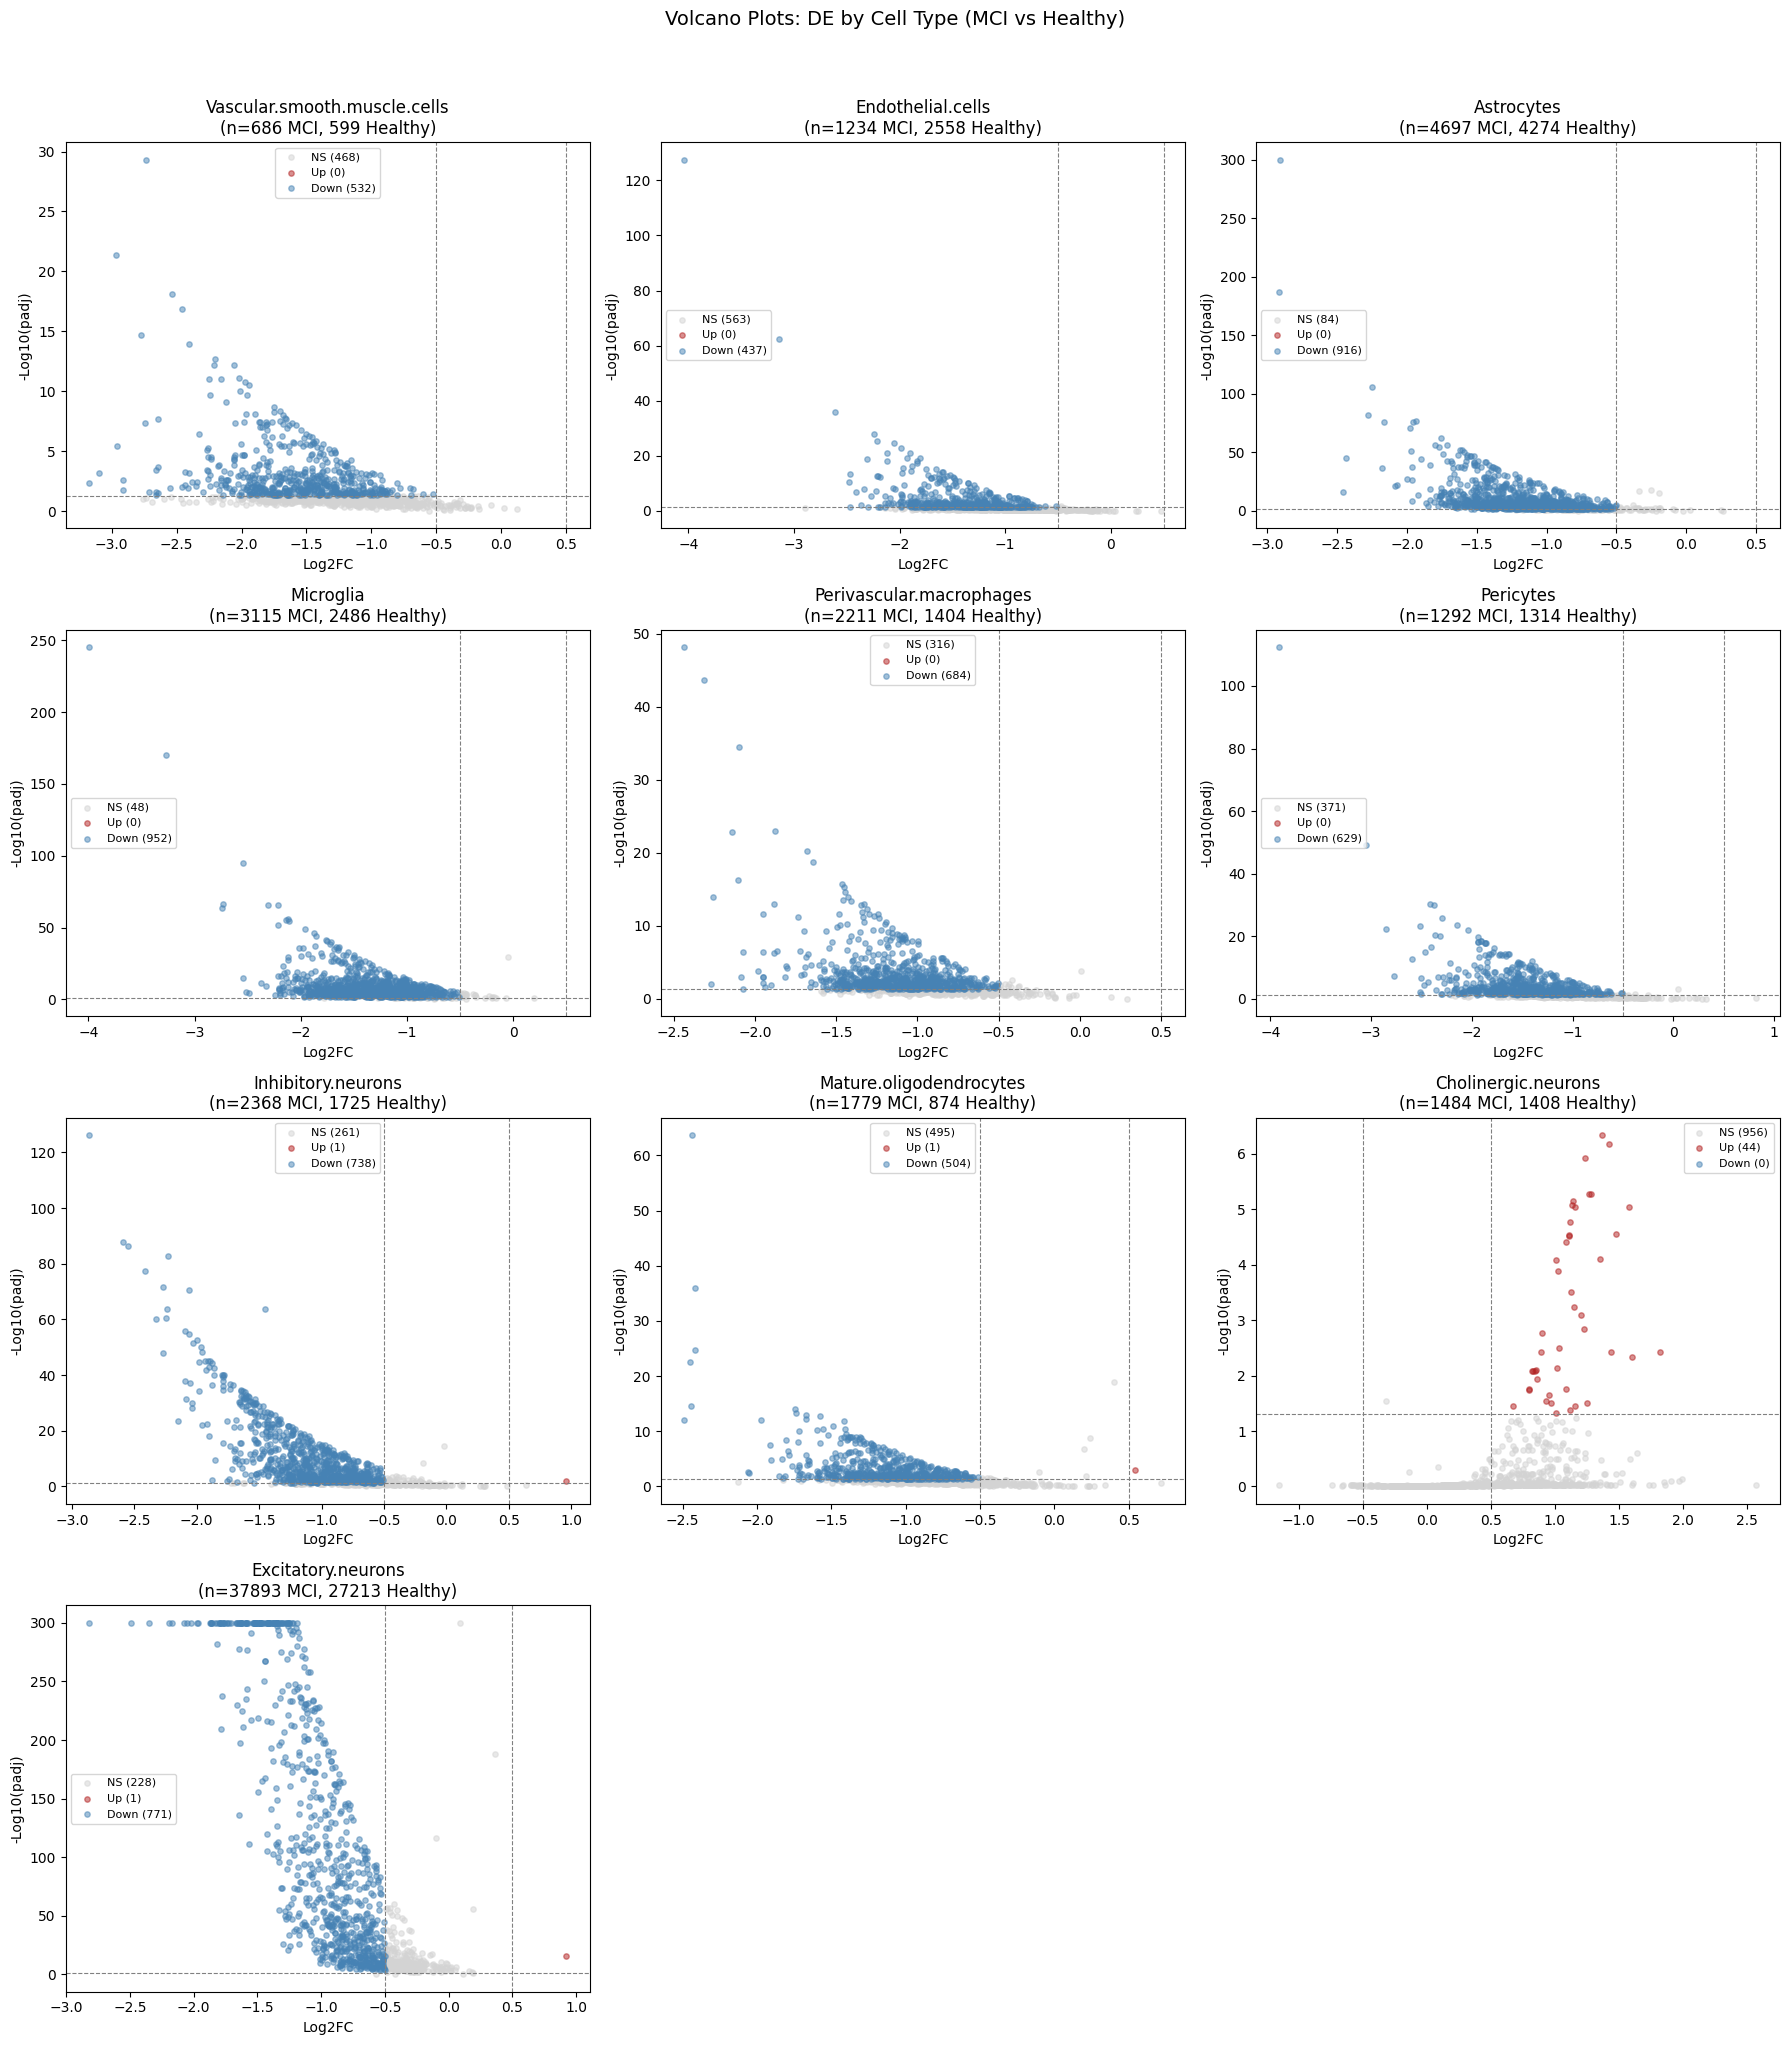

In [108]:
# -----------------------------------------------------------------------------
# 6. VOLCANO PLOTS - CELL TYPE STRATIFIED
# -----------------------------------------------------------------------------

print("Creating volcano plots for cell type stratified analysis...")

# Calculate grid dimensions
n_plots = len([ct for ct in target_cell_types if ct in de_by_celltype])
if n_plots > 0:
    n_cols = min(3, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    plot_idx = 0
    for ct in target_cell_types:
        if ct in de_by_celltype:
            df = de_by_celltype[ct].copy()
            
            # Prepare data
            df['log2FC'] = df['logfoldchanges']
            df['pval'] = df['pvals_adj']
            df['neg_log10_pval'] = -np.log10(df['pval'].clip(lower=1e-300))
            
            # Classify
            df['sig'] = 'NS'
            df.loc[(df['log2FC'] > 0.5) & (df['pval'] < 0.05), 'sig'] = 'Up'
            df.loc[(df['log2FC'] < -0.5) & (df['pval'] < 0.05), 'sig'] = 'Down'
            
            ax = axes[plot_idx]
            colors = {'NS': 'lightgray', 'Up': 'firebrick', 'Down': 'steelblue'}
            
            for sig, color in colors.items():
                mask = df['sig'] == sig
                ax.scatter(df.loc[mask, 'log2FC'], df.loc[mask, 'neg_log10_pval'],
                          c=color, alpha=0.5, s=15, label=f"{sig} ({mask.sum()})")
            
            ax.axhline(-np.log10(0.05), color='gray', linestyle='--', lw=0.8)
            ax.axvline(0.5, color='gray', linestyle='--', lw=0.8)
            ax.axvline(-0.5, color='gray', linestyle='--', lw=0.8)
            
            ax.set_xlabel('Log2FC')
            ax.set_ylabel('-Log10(padj)')
            ax.set_title(f'{ct}\n(n={de_by_celltype[ct]["n_cells_test"].iloc[0]} MCI, {de_by_celltype[ct]["n_cells_ref"].iloc[0]} Healthy)')
            ax.legend(fontsize=8)
            
            plot_idx += 1
    
    # Hide empty axes
    for i in range(plot_idx, len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle('Volcano Plots: DE by Cell Type (MCI vs Healthy)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No DE results available for cell type analysis")


Creating volcano plots for region stratified analysis...


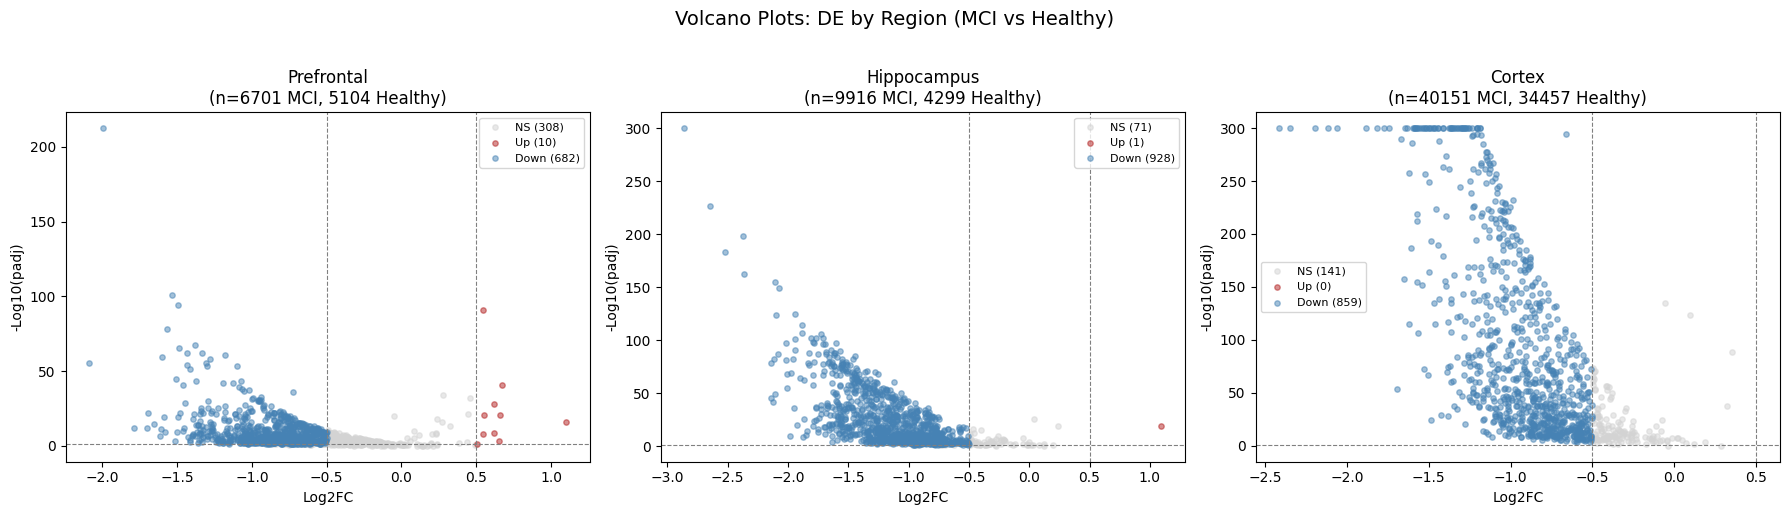

In [109]:
# -----------------------------------------------------------------------------
# 7. VOLCANO PLOTS - REGION STRATIFIED
# -----------------------------------------------------------------------------

print("Creating volcano plots for region stratified analysis...")

n_plots = len([r for r in target_regions if r in de_by_region])
if n_plots > 0:
    fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    
    plot_idx = 0
    for region in target_regions:
        if region in de_by_region:
            df = de_by_region[region].copy()
            
            df['log2FC'] = df['logfoldchanges']
            df['pval'] = df['pvals_adj']
            df['neg_log10_pval'] = -np.log10(df['pval'].clip(lower=1e-300))
            
            df['sig'] = 'NS'
            df.loc[(df['log2FC'] > 0.5) & (df['pval'] < 0.05), 'sig'] = 'Up'
            df.loc[(df['log2FC'] < -0.5) & (df['pval'] < 0.05), 'sig'] = 'Down'
            
            ax = axes[plot_idx]
            colors = {'NS': 'lightgray', 'Up': 'firebrick', 'Down': 'steelblue'}
            
            for sig, color in colors.items():
                mask = df['sig'] == sig
                ax.scatter(df.loc[mask, 'log2FC'], df.loc[mask, 'neg_log10_pval'],
                          c=color, alpha=0.5, s=15, label=f"{sig} ({mask.sum()})")
            
            ax.axhline(-np.log10(0.05), color='gray', linestyle='--', lw=0.8)
            ax.axvline(0.5, color='gray', linestyle='--', lw=0.8)
            ax.axvline(-0.5, color='gray', linestyle='--', lw=0.8)
            
            ax.set_xlabel('Log2FC')
            ax.set_ylabel('-Log10(padj)')
            ax.set_title(f'{region}\n(n={de_by_region[region]["n_cells_test"].iloc[0]} MCI, {de_by_region[region]["n_cells_ref"].iloc[0]} Healthy)')
            ax.legend(fontsize=8)
            
            plot_idx += 1
    
    plt.suptitle('Volcano Plots: DE by Region (MCI vs Healthy)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No DE results available for region analysis")


In [110]:
# -----------------------------------------------------------------------------
# 8. SAVE RESULTS & FINAL SUMMARY
# -----------------------------------------------------------------------------

# Define output directory
output_dir = r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\DE_results"
import os
os.makedirs(output_dir, exist_ok=True)

# Save summary tables
summary_ct_df.to_csv(os.path.join(output_dir, "DE_summary_by_celltype.csv"), index=False)
summary_region_df.to_csv(os.path.join(output_dir, "DE_summary_by_region.csv"), index=False)
summary_combo_df.to_csv(os.path.join(output_dir, "DE_summary_by_combination.csv"), index=False)

# Save full DE results
for ct, df in de_by_celltype.items():
    safe_name = ct.replace('.', '_').replace(' ', '_')
    df.to_csv(os.path.join(output_dir, f"DE_celltype_{safe_name}.csv"), index=False)

for region, df in de_by_region.items():
    safe_name = region.replace('.', '_').replace(' ', '_')
    df.to_csv(os.path.join(output_dir, f"DE_region_{safe_name}.csv"), index=False)

for combo, df in de_combinations.items():
    safe_name = combo.replace('.', '_').replace(' ', '_').replace('|', '_')
    df.to_csv(os.path.join(output_dir, f"DE_combo_{safe_name}.csv"), index=False)

print("=" * 70)
print("DIFFERENTIAL EXPRESSION ANALYSIS COMPLETE")
print("=" * 70)
print(f"\nResults saved to: {output_dir}")
print(f"\nFiles created:")
print(f"  - DE_summary_by_celltype.csv")
print(f"  - DE_summary_by_region.csv") 
print(f"  - DE_summary_by_combination.csv")
print(f"  - {len(de_by_celltype)} cell type DE result files")
print(f"  - {len(de_by_region)} region DE result files")
print(f"  - {len(de_combinations)} combination DE result files")

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print("\n📊 BY CELL TYPE (pooled across regions):")
print(summary_ct_df[['stratum', 'n_cells_MCI', 'n_cells_Healthy', 'n_up_MCI', 'n_down_MCI']].to_string(index=False))

print("\n📊 BY REGION (pooled across cell types):")
print(summary_region_df[['stratum', 'n_cells_MCI', 'n_cells_Healthy', 'n_up_MCI', 'n_down_MCI']].to_string(index=False))

print("\n📊 COMBINATIONS WITH SIGNIFICANT DEGs:")
sig_combos = summary_combo_df[(summary_combo_df['n_up_MCI'] > 0) | (summary_combo_df['n_down_MCI'] > 0)]
if len(sig_combos) > 0:
    print(sig_combos[['stratum', 'n_cells_MCI', 'n_cells_Healthy', 'n_up_MCI', 'n_down_MCI']].to_string(index=False))
else:
    print("  No combinations with significant DEGs found")

print("\n✓ Analysis complete!")


DIFFERENTIAL EXPRESSION ANALYSIS COMPLETE

Results saved to: C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\DE_results

Files created:
  - DE_summary_by_celltype.csv
  - DE_summary_by_region.csv
  - DE_summary_by_combination.csv
  - 10 cell type DE result files
  - 3 region DE result files
  - 30 combination DE result files

FINAL SUMMARY

📊 BY CELL TYPE (pooled across regions):
                     stratum  n_cells_MCI  n_cells_Healthy  n_up_MCI  n_down_MCI
Vascular.smooth.muscle.cells          686              599         0         532
           Endothelial.cells         1234             2558         0         437
                  Astrocytes         4697             4274         0         916
                   Microglia         3115             2486         0         952
    Perivascular.macrophages         2211             1404         0         684
                   Pericytes         1292             1314     

In [57]:
adata_hv = adata_full[~adata_full.obs['sample_ID'].isin(['070L','732L'])]
adata_hv.obs['sample_ID'].unique()

array(['674L', '539B', '380R', '537B'], dtype=object)

In [75]:
# Check if one group is just "richer" in data than the other
print(adata_full.obs.groupby('FMT')['total_counts'].describe())
print("\n\n")
# Check if specific samples are outliers in quality
print(adata_full.obs.groupby(['FMT', 'sample_ID'])['total_counts'].median())

            count        mean         std   min   25%    50%    75%      max
FMT                                                                         
Healthy  193175.0  378.497409  437.566175  20.0  75.0  221.0  536.0  10406.0
MCI      239644.0  187.115909  190.654198  20.0  70.0  130.0  234.0   6633.0



FMT      sample_ID
Healthy  070L          59.0
         539B         366.0
         674L         398.0
MCI      380R         205.0
         537B         127.0
         732L          80.0
Name: total_counts, dtype: float64


In [65]:
# See the breakdown of cells per sample in each group
print(pd.crosstab(adata_full.obs['sample_ID'], adata_full.obs['FMT']))

FMT        Healthy    MCI
sample_ID                
070L         56322      0
380R             0  97041
537B             0  76577
539B         70559      0
674L         66294      0
732L             0  66026


In [64]:
sc.pp.regress_out(adata_full, ['total_counts'])

c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\scanpy\preprocessing\_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\scanpy\preprocessing\_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


In [72]:
full_de=ezy.rank_DE(
    adata_full,
    method='logreg',
    groupby="FMT",
    comparisons=[['Healthy','MCI']],
    #extra_filter={"ct_simple": ["Microglia"],
    #"napari_region":["Hippocampus"]}  # optional extra filters
)
adata_hv = adata_full[~adata_full.obs['sample_ID'].isin(['380R','070L'])]
sub_de=ezy.rank_DE(
    adata_hv,
    method='logreg',
    groupby="FMT",
    comparisons=[['Healthy','MCI']],
    #extra_filter={"ct_simple": ["Microglia"],
    #"napari_region":["Hippocampus"]}  # optional extra filters
)

on the else cond.
[['Healthy', 'MCI']]
on the else cond.
[['Healthy', 'MCI']]


update working


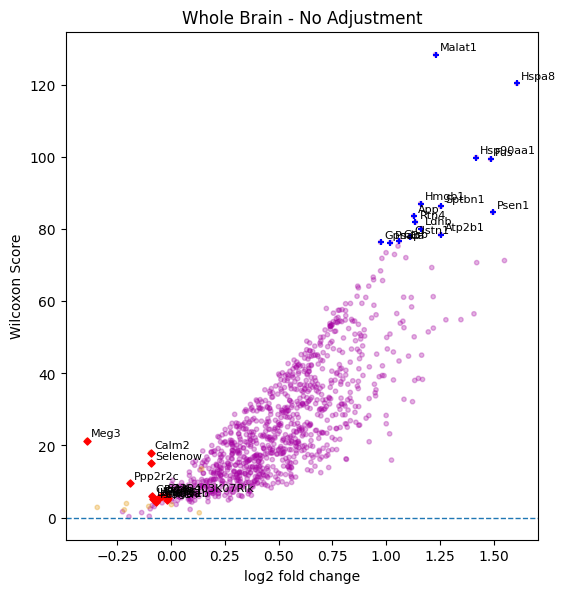

update working


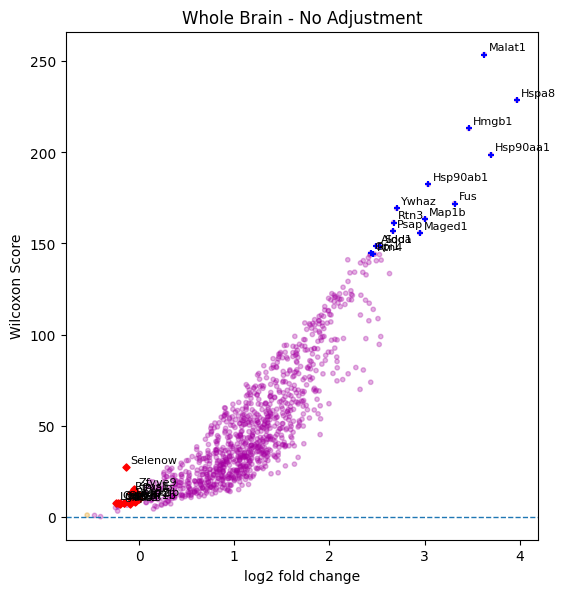

In [73]:
hl=ezy.plot.volcano(
    full_de,
    y_axis='score',
    default_colors=["#A500A2FF","#E39400FF"],
    #bold_colors=["#A500A2FF","#E39400FF"],
    balance_labels=True,
    return_highlights=True,
    top_labels=30,
    figsize=(6.1,6.6),
    sig_markers=["+", "D"],
    title='Whole Brain - No Adjustment'
)
h2=ezy.plot.volcano(
    sub_de,
    y_axis='score',
    default_colors=["#A500A2FF","#E39400FF"],
    #bold_colors=["#A500A2FF","#E39400FF"],
    balance_labels=True,
    return_highlights=True,
    top_labels=30,
    figsize=(6.1,6.6),
    sig_markers=["+", "D"],
    title='Whole Brain - No Adjustment'
)